# Esame Laboratorio di Programmazione II - 22/07/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e rinominate il file che consegnate come `matricola.ipynb` (la matricola è SMnumeri o ECnumeri).

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domande e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB: Potete usare anche più di una cella python per domanda e se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza etichette sugli assi o illeggibili sarà valutato meno bene di uno con etichette chiare.

Cercate di commmentare il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [ ]:
#AURORA GARDISAN SM32A00056

In [63]:
#LIBRERIE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit


## Esercizio 1

Crea un vettore NumPy con le seguenti spese annuali per l’auto (in euro) sostenute da 7 persone:
3200, 2750, 4100, 3600, 2950, 5100, 4400

1. Calcola la spesa totale complessiva sostenuta dal gruppo.

2. Le persone con spese minori di 3000 € ottengono una detrazione fiscale del 15%. Applica la modifica al vettore.

3. Quanto ha risparmiato il gruppo dopo la detrazione fiscale?


In [3]:
spese = np.array([3200, 2750, 4100, 3600, 2950, 5100, 4400], dtype=float)
#1
spesa_tot = np.sum(spese)
print("Spesa totale sostenuta : ", spesa_tot)
#2
condizione = spese<3000
spese[condizione] = spese[condizione] * 0.85
print("Array con le spese aggiornato con la detrazione fiscale: ", spese)
#3
risparmio = spesa_tot - np.sum(spese)
print(f"Il gruppo ha risparmiato {risparmio} euro")

Spesa totale sostenuta :  26100.0
Array con le spese aggiornato con la detrazione fiscale:  [3200.  2337.5 4100.  3600.  2507.5 5100.  4400. ]
Il gruppo ha risparmiato 855.0 euro


## Esercizio 2
1. Scrivi una funzione che simula il lancio di un dado per N volte e restituisce un array con il numero di volte che è uscita ciascuna faccia (da 1 a 6).
2. Calcolare la frequenza % con la dimensione del campione (numero di lanci) 100 volte da 10 a 5000.  Ottieni così 100 array di frequenze.
3. Fai il plot dell’andamento della frequenza media delle facce 1, 3 e 6 in funzione della dimensione del campione.



In [7]:
np.random.seed(0)
#1
def lancio_dado(N):
    lanci = np.random.randint(1,7, size = N)
    conteggi = np.bincount(lanci)
    return(conteggi[1:])
#2
dimensioni = np.linspace(10,5000,100, dtype=int)
freq_totali = []
for N in dimensioni:
    conteggio = lancio_dado(N)
    freq_perc = (conteggio/N)*100
    freq_totali.append(freq_perc)
print("Freq. percentuale con dimensione del campione: ", freq_totali)
#3


Freq. percentuale con dimensione del campione:  [array([10., 10., 10., 40., 10., 20.]), array([21.66666667, 23.33333333, 13.33333333, 18.33333333, 13.33333333,
       10.        ]), array([19.09090909,  9.09090909, 19.09090909, 22.72727273, 15.45454545,
       14.54545455]), array([18.01242236, 17.39130435, 11.80124224, 19.8757764 , 12.42236025,
       20.49689441]), array([17.53554502, 16.58767773, 13.74407583, 20.37914692, 18.48341232,
       13.27014218]), array([12.59541985, 17.17557252, 21.3740458 , 14.88549618, 17.17557252,
       16.79389313]), array([16.66666667, 16.34615385, 13.78205128, 17.62820513, 15.38461538,
       20.19230769]), array([17.40331492, 14.36464088, 16.85082873, 17.40331492, 18.2320442 ,
       15.74585635]), array([17.91767554, 17.67554479, 16.46489104, 17.19128329, 14.04358354,
       16.70702179]), array([13.39092873, 16.84665227, 16.1987041 , 19.43844492, 15.55075594,
       18.57451404]), array([14.20233463, 17.3151751 , 16.73151751, 18.28793774, 16.7315

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 7 x 7, con valori estratti da una distribuzione normale con media = 0, ed std = 5.

2. Per ogni riga, identifica il valore più lontano da zero (cioè con valore assoluto massimo). Crea un array con questi 7 valori (uno per riga).

3. Calcola quante di queste righe hanno il valore più lontano da zero positivo?

In [13]:
#1
matrice = np.random.normal(loc=0, scale=5, size=(7,7))
print("Matrice:", matrice)
#2
matrice_assoluta = np.abs(matrice)
indici_massimi = np.argmax(matrice_assoluta, axis=1)
valori_lontani = matrice[np.arange(7), indici_massimi]
print("Array con valori distanza massima da zero per ciascuna riga:", valori_lontani)
#3
vero_falso = valori_lontani > 0
somma = np.sum(vero_falso)
print("Numero di righe che hanno valore più lontano da zero positivo: ", somma)

Matrice: [[ -5.33326668  -4.03251859  -2.58646991   0.56256336  -4.30902067
   -5.01352495   0.54401853]
 [  4.26530641  12.4037885   -2.02167486  -3.05909099   2.24003124
    0.61601108   1.16900933]
 [  4.96002911  -4.33703744   1.7733244   -3.7658555   -5.85556691
    2.81406947  -2.0752491 ]
 [  1.55270355 -12.37994146   8.39678765   8.76859829   0.95620813
    1.25728762  -2.99428535]
 [  0.37086774  -1.34988271  -6.07436556  -8.59723244   1.30084394
    3.18994727  -0.63620952]
 [ -2.7066726   -5.03792071   2.16896094   2.32956764  -1.84450465
    0.49093035  -2.87459588]
 [ -2.50724318   1.5991875   -3.8522782    4.57276506  -2.04284015
    7.45556712   7.02389623]]
Array con valori distanza massima da zero per ciascuna riga: [ -5.33326668  12.4037885   -5.85556691 -12.37994146  -8.59723244
  -5.03792071   7.45556712]
Numero di righe che hanno valore più lontano da zero positivo:  2


## Esercizio 4 

Utilizza il dataset cereal.csv.

Contiene dati nutrizionali (proteine, fibre, calorie, zuccheri, ecc.) per circa 70 cereali.


1.  Aggiungi una colonna chiamata `nutri_score`, definita come:
$$
\texttt{nutri\_score} = \frac{\texttt{protein} + \texttt{fiber}}{\texttt{calories}}
$$

Indica quanti nutrienti positivi ci sono per ogni caloria: più è alto, più il cereale è "nutriente a parità di energia.

2. Trova i **5 cereali con il `nutri_score` più alto** e stampali con `name` e `nutri_score`.

3. Filtra i cereali che soddisfano entrambi i criteri:

   - meno di 120 calorie  
   - più di 2 grammi di fibra 


4. **Crea un grafico a barre** dei **10 cereali con il `nutri_score` più alto**, usando `name` sull’asse x.

5. Crea uno **scatter plot** (grafico a punti) che visualizzi:

   - `calories` sull’asse x  
   - `nutri_score` sull’asse y
   - `protein` nel colore dei punti


5Cereali con nutri score piu alto:
                           name  nutri_score
3   All-Bran with Extra Fiber     0.360000
0                   100% Bran     0.200000
2                    All-Bran     0.185714
9                 Bran Flakes     0.088889
64     Shredded Wheat 'n'Bran     0.077778

Cereali che rispettano le condizioni:
                          name mfr type  calories  protein  fat  sodium  fiber  \
0                   100% Bran   N    C        70        4    1     130   10.0   
2                    All-Bran   K    C        70        4    1     260    9.0   
3   All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
8                   Bran Chex   R    C        90        2    1     200    4.0   
9                 Bran Flakes   P    C        90        3    0     210    5.0   
19         Cracklin' Oat Bran   K    C       110        3    3     140    4.0   
26        Frosted Mini-Wheats   K    C       100        3    0       0    3.0   
32          Grape

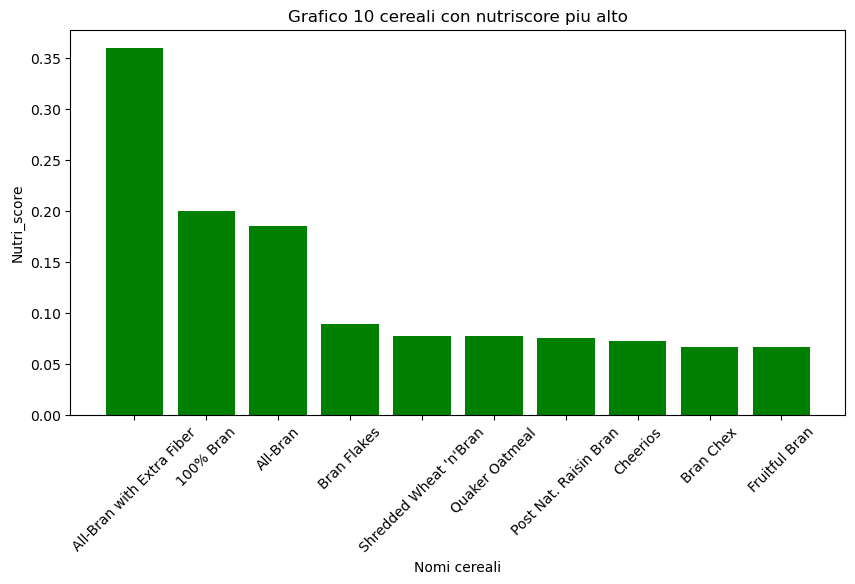

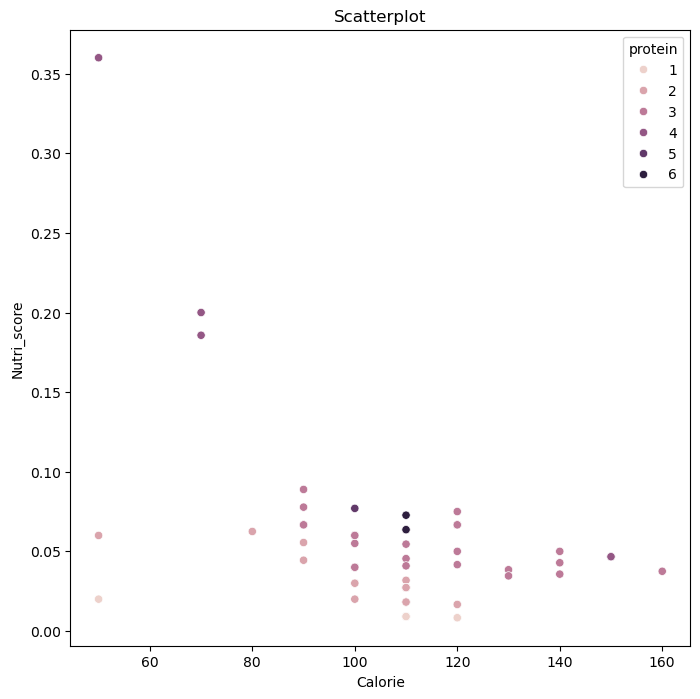

In [35]:
df = pd.read_csv("cereal.csv", sep =";")
#1
df["nutri_score"] = (df["protein"]+df["fiber"])/df["calories"]
#2
top_5_cer = df.sort_values(by="nutri_score", ascending=False).head(5)
print("5Cereali con nutri score piu alto:\n ", top_5_cer[["name", "nutri_score"]])
#3
vero_falso = ((df["calories"]<120) & (df["fiber"]>2))
cereali_filtrati = df[vero_falso]
print("\nCereali che rispettano le condizioni:\n",cereali_filtrati)
#4
nutri_max = df.sort_values(by="nutri_score", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(nutri_max["name"], nutri_max["nutri_score"], color="green")
plt.title("Grafico 10 cereali con nutriscore piu alto")
plt.xlabel("Nomi cereali")
plt.ylabel("Nutri_score")
plt.xticks(rotation=45)
plt.show()
#5
plt.figure(figsize=(8,8))
sns.scatterplot(data = df, x = "calories", y="nutri_score", hue="protein")
plt.title("Scatterplot")
plt.xlabel("Calorie")
plt.ylabel("Nutri_score")
plt.show()

## Esercizio 5 

Utilizza il dataset `imdb_top_1000.csv`, che contiene informazioni su 1000 film recensiti su IMDB.

1. Quanti **valori mancanti** ci sono per colonna? Elimina le righe con i valori mancanti.

2. Elimina la colonna `Overview`. Aggiungi una colonna (`main_genre`) con solo il primo genere della colonna `genre`. Quali sono i 5 generi più frequenti?

3. Che attore/attrice è stato/a più volte la `Star1` e quello/a che ha fatto più film.

4. Calcola l'IMDB_rating medio e il Gross medio di ogni genere. Fai uno scatter plot dell'IMDB_rating medio e il Gross medio di ogni genere. Riesci a mettere anche l'ettichetta del genere?

5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).




Generi più frequenti:  main_genre
Drama        192
Action       127
Comedy       104
Crime         74
Biography     73
Name: count, dtype: int64
Attore che è stato più volte Star1:  Tom Hanks

IMDB_rating medio:
  main_genre
Action       7.937008
Adventure    7.927586
Animation    7.926984
Biography    7.916438
Comedy       7.877885
Crime        8.012162
Drama        7.941667
Family       7.800000
Film-Noir    8.100000
Horror       7.933333
Mystery      8.071429
Western      8.350000
Name: IMDB_Rating, dtype: float64

Gross medio:
  main_genre
Action       1.568238e+08
Adventure    8.919198e+07
Animation    1.359713e+08
Biography    6.471483e+07
Comedy       3.888455e+07
Crime        4.246059e+07
Drama        4.682345e+07
Family       2.195553e+08
Film-Noir    4.491910e+05
Horror       8.175208e+07
Mystery      3.840551e+07
Western      1.455538e+07
Name: Gross, dtype: float64


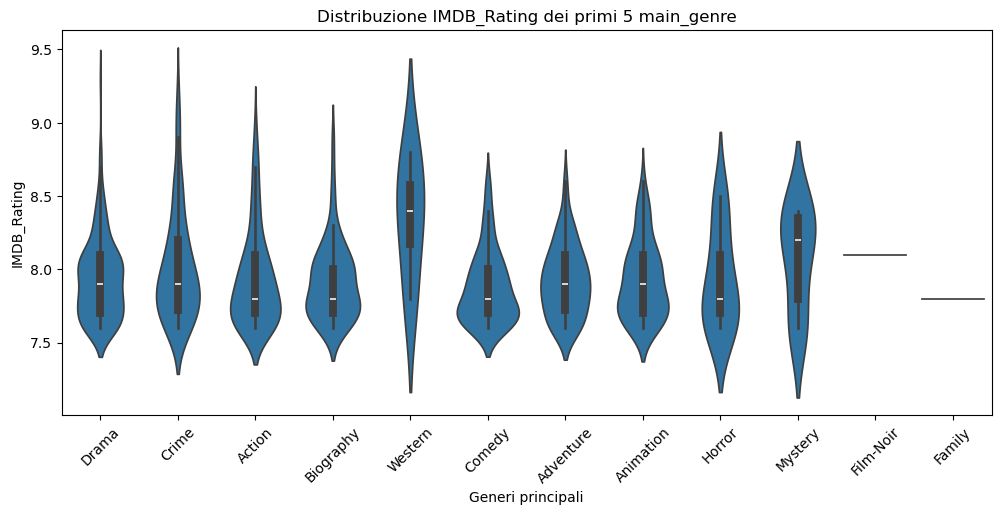

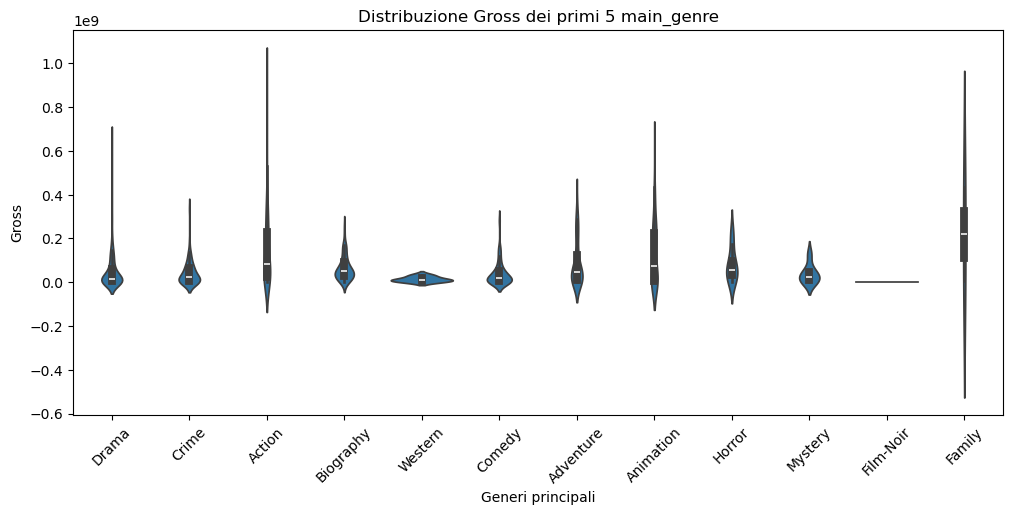

In [62]:
df = pd.read_csv("imdb_top_1000.csv")
#1
valori_manc = df.isnull().sum()
df = df.dropna()
#2
df = df.drop(columns="Overview")
df["main_genre"] = df["Genre"].str.split(",").str[0]
df.head()
piu_freq = df["main_genre"].value_counts().head(5)
print("Generi più frequenti: ", piu_freq)
#3
attore_freq = df["Star1"].mode()[0]
print("Attore che è stato più volte Star1: ", attore_freq)
#4
imdb_rating_medio = df.groupby("main_genre")["IMDB_Rating"].mean()
print("\nIMDB_rating medio:\n ", imdb_rating_medio)
if df["Gross"].dtype == "0":
    df["Gross"]=df["Gross"].str.replace(",", "").astype(float)
gross_medio = df.groupby("main_genre")["Gross"].mean()
print("\nGross medio:\n ", gross_medio)
#5
df_ordinato = df.sort_values(by="main_genre", ascending=False)
plt.figure(figsize=(12,5))
sns.violinplot(data=df, x ="main_genre", y="IMDB_Rating")
plt.title("Distribuzione IMDB_Rating dei primi 5 main_genre")
plt.xlabel("Generi principali")
plt.ylabel("IMDB_Rating")
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(12,5))
sns.violinplot(data=df, x="main_genre", y="Gross")
plt.title("Distribuzione Gross dei primi 5 main_genre")
plt.xlabel("Generi principali")
plt.ylabel("Gross")
plt.xticks(rotation=45)
plt.show()

## Esercizio 6

Considera i seguenti dati, che :

`x = np.linspace(0, 10, 100)`  
`y = -3.5 * x + 2 + np.random.normal(0, 10, 100)`

Cerca di riprodurre la retta fittando i parametri della funzione y = ax + b.

1. Stima i parametri della retta.
2. Calcola l’intervallo di confidenza al 95% dei parametri a e b.
N.B il secondo output del metodo curve_fit è proprio la matrice di covarianza: `params, cov = curve_fit(retta, x, y)`. 
L'**errore standard** di ciascun parametro si calcola come:

$$
\text{errore\_standard}_i = \sqrt{\text{cov}(i, i)}
$$

dove $\text{cov}(i, i)$ è l'elemento diagonale $i$-esimo della **matrice di covarianza**.

L’**intervallo di confidenza al 95%** si approssima con:

$$
\text{parametro}_i \pm 1.96 \times \text{errore\_standard}_i
$$
3. Plotta i punti originali e la retta ottenuta con anche l'intervallo di confidenza


Intervallo confidenza a: [-4.471158766352613, -3.025256342620115]. 
 Intervallo confidenza b: [(np.float64(0.07175984779669786), np.float64(8.44073539964683))]


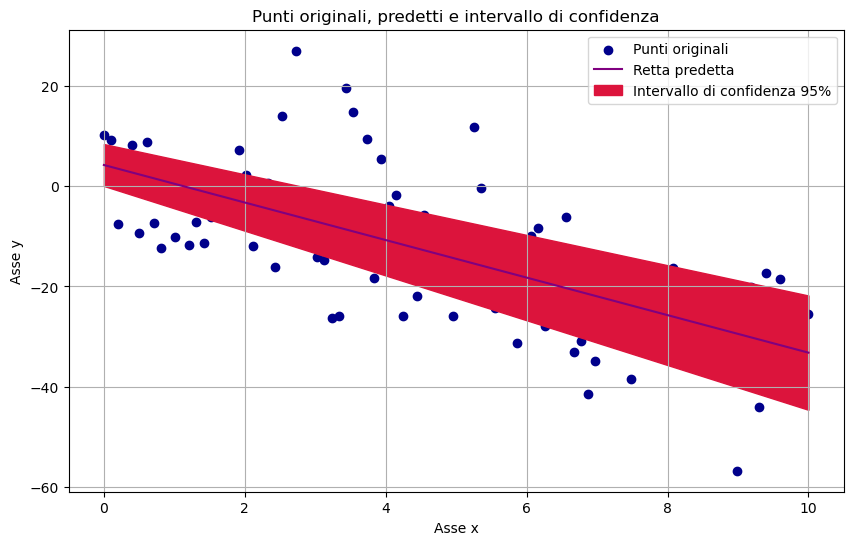

In [65]:
x = np.linspace(0, 10, 100)
y = -3.5 * x + 2 + np.random.normal(0, 10, 100)
#1
def modello_retta(x, a, b):
    return (a*x)+b
param_predetti ,cov = curve_fit(modello_retta, x, y)
a_pred , b_pred = param_predetti
y_pred = modello_retta(x,a_pred,b_pred)
#2
cov_i = np.diag(cov)
errore_stand = np.sqrt(cov_i)
err_a = errore_stand[0]
err_b = errore_stand[1]
ic_a_min, ic_a_max = a_pred - 1.96*err_a, a_pred + 1.96*err_a
ic_b_min, ic_b_max = b_pred - 1.96*err_b, b_pred + 1.96*err_b
print(f"\nIntervallo confidenza a: [{ic_a_min}, {ic_a_max}]. \n Intervallo confidenza b: [{ic_b_min, ic_b_max}]")
#3
plt.figure(figsize=(10,6))
plt.scatter(x, y, color="darkblue", label = "Punti originali")
plt.plot(x, y_pred, color="purple", label ="Retta predetta")
y_pred_min = modello_retta(x, ic_a_min, ic_b_min)
y_pred_max = modello_retta(x, ic_a_max, ic_b_max)
plt.fill_between(x, y_pred_min, y_pred_max, color="crimson", label = "Intervallo di confidenza 95%")
plt.title("Punti originali, predetti e intervallo di confidenza")
plt.xlabel("Asse x")
plt.ylabel("Asse y")
plt.legend()
plt.grid(True)
plt.show()

